uni_section_v7: command_v7.md 근본 수정 + /synod design 세션 설계 결정 통합
  - alpha를 collision masking 전용으로 완전 분리 (t_final = t_new, alpha 미곱)
  - GHOST_STEEPNESS 20→5, 하한 클램프 → soft(logit-sigmoid) clamp
  - 커리큘럼: collision 항상 최우선(1.0 고정) + phys는 0.2에서 시작해 ramp
  - 좌표 anchor 정규화(L2) 추가로 형상 발산 방지
  - Dual-threshold Feasibility Checkpointing: Mp err<2% AND collision<0.05 동시 만족 추적
  - alpha 포화 파트 수 모니터링

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])

[ uni_section_v7 ] Training  |  Target Mp = 47,421,470 N·mm  |  Epochs: 250
  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: True (0.2, 0.7)
  (alpha: collision 전용 분리 / GHOST_STEEPNESS=5.0 / soft thickness clamp)
  Feasibility 기준: Mp err < 2.0%  AND  l_collision < 0.05
Epoch ||  Loss  ||  MpErr% |  Smth  |  Area  |  Mass  |  Coll  | Anchor ||  alpha(mean/min)  | satParts
00000 || 1032.2262 ||  43.87% | 0.3333 | 1241.6 | 0.0012 | 206.1790 | 0.1265 || 0.998 / 0.995 | 5/5
00019 || 582.8513 ||  73.07% | 0.3318 |  591.2 | 0.0006 | 116.2281

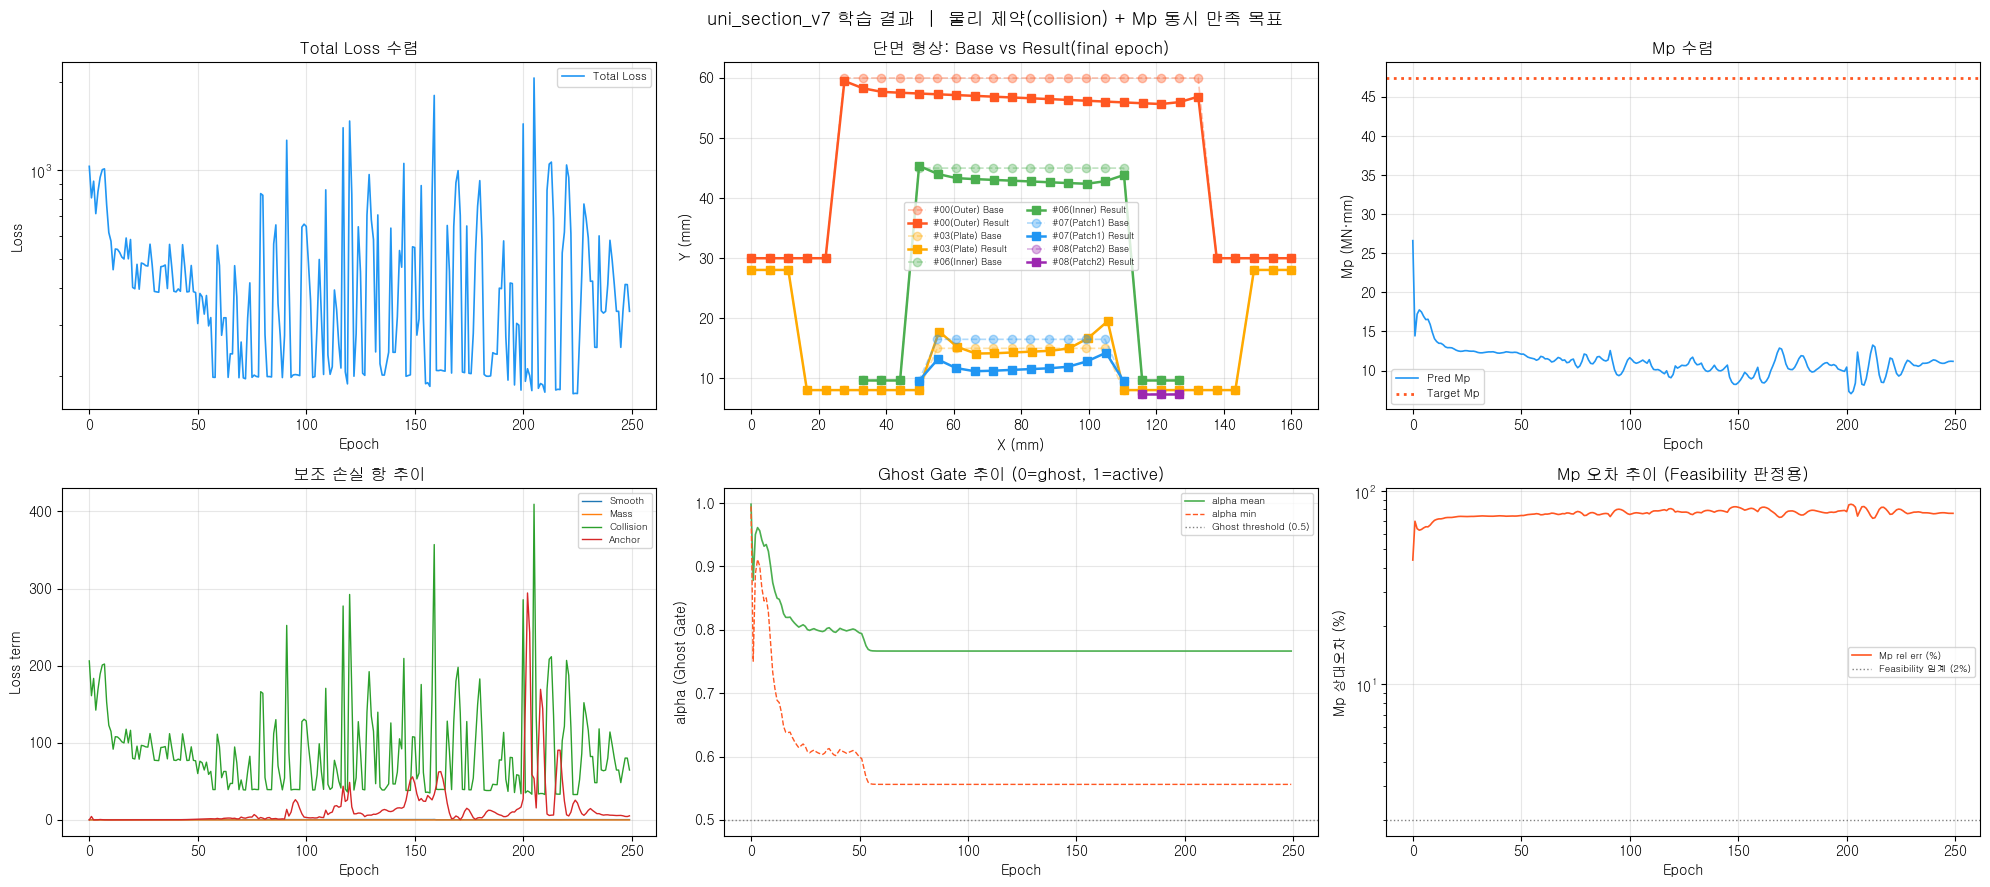


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\CGNN\uni-section\uni_section_v7_result.png

최종 결과 요약 (마지막 epoch 기준)
  Target Mp     :     47,421,470 N·mm
  Final pred_mp :     11,182,746 N·mm
  Final Error   :  76.42%
  Final l_collision : 64.6848
  Final alpha   : mean=0.766 / min=0.556

  ⚠ Feasible 모델을 찾지 못함 — feasibility_mp_err/feasibility_collision 완화 또는 max_epochs 증가, 가중치 재조정 필요.


In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
uni_section_v7.py
─────────────────────────────────────
uni_section_v6.py의 학습 정체(freeze) 문제를 docs/command_v7.md 수정 사항 +
/synod design 세션(synod-20260710-093602-7032cd, Gemini flash + OpenAI o3 실제 병렬 교차검증,
conf 95%/93%, 조기 합의)에서 도출된 설계 결정을 반영해 재작성한 버전.

목표(사용자 명시): 단일 섹션 B-Pillar 구조가 "물리적 제약(파트 간 침투 방지)을 만족하면서
목표 전소성 모멘트(target Mp)를 동시에 만족"시키는 것.

docs/command_v7.md 반영 사항 (근본 수정):
  §2.1 [최우선] alpha를 collision masking 전용으로 완전 분리: t_final = t_new (alpha 곱하지 않음).
       phys/mass loss가 "두께를 키워라" 신호를 보낼 때 collision loss가 "두께를 줄여 회피"하는
       경쟁 신호를 더 이상 만들지 않는다.
  §2.2 GHOST_STEEPNESS 20.0 → 5.0 (시그모이드 포화 구간 완화).
  §2.3 하한 클램프를 soft clamp(로짓-시그모이드 매핑)로 교체 — 하한 근처에서도 gradient가
       완전히 0이 되지 않도록 함.
  §2.4 손실 가중치 재조정 (w_phys 20→10, w_collision 2→5).
  §2.5 회복 여지 확대: DELTA_SCALE 유지(1.5) + soft clamp 자체가 이미 회복 경로를 열어줌.

/synod design 세션 합의 사항 (Gemini·OpenAI 공통, 추가 설계 결정):
  D1 커리큘럼을 "collision 우선" 순서로 재설계: 물리 제약(충돌 방지)은 처음부터 강하게,
     Mp는 그 위에서 미세조정 — 두 자유도(좌표·두께)가 동시에 풀리며 상충하지 않도록 시간차를 둠.
  D2 좌표 변형에 anchor 정규화(L2, `compute_anchor_loss`) 추가 — 두께 자유도로 Mp를 맞추는 동안
     좌표가 불필요하게 발산해 형상이 무너지는 것을 억제 (Gemini 제안).
  D3 Dual-threshold Feasibility Checkpointing — "Mp 오차 < 2%"와 "collision loss < 임계값"을
     동시에 만족하는 최고 시점을 별도로 추적·저장 (양쪽 모델 공통 제안). 단순 total loss
     최소화가 아니라 "물리 제약 + 목표 동시 만족"을 직접 판정.
  D4 모니터링 세이프가드 — alpha가 포화(0 또는 1 근처)된 파트 개수를 매 로그마다 출력 (OpenAI 제안).

v6와 동일하게 유지되는 부분 (변경 없음):
  - ImplicitPNASolver, build_bpillar_section() 초기 좌표·fix point·엣지 구성
  - l_phys 형태(sqrt(abs(err_ratio)))
  - collision의 인접쌍(i, i+1) 검사 방식, Patch(3,4) 포함
  - keepout/continuity/shape 항 미사용
"""

import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'  # Windows 한글 폰트

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: ImplicitPNASolver  (pna_solver_validate_v9.py 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산
    엣지 두께를 Y축으로 투영하여 수평 엣지도 연속적으로 처리 → 평형 잔차 ≈ 0.
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Edge-based 이분탐색으로 순 축력 = 0인 y_pna 탐색 (평형 잔차 ~1e-8)
    Backward: IFT + ∂Mp/∂y_pna = 0 (평형 조건) → y_pna 고정 하에서 직접 미분만 계산
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=40):
        mp_pred, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)

        mask = edge_index[0] < edge_index[1]
        ctx.save_for_backward(coords, t, fy, y_pna.reshape(1), edge_index)
        ctx.mask = mask
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        mask = ctx.mask
        y_pna = y_pna_buf[0].detach()

        with torch.enable_grad():
            coords_g = coords.detach().requires_grad_(True)
            u, v = edge_index[0][mask], edge_index[1][mask]
            y_u, y_v = coords_g[u, 1], coords_g[v, 1]
            x_u, x_v = coords_g[u, 0], coords_g[v, 0]
            L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
            t_e  = t[u].squeeze(-1)
            fy_e = fy[u].squeeze(-1)

            dx_b   = torch.abs(x_u - x_v)
            t_y_b  = t_e * (dx_b / (L + 1e-12))
            y_max  = torch.maximum(y_u, y_v)
            y_min  = torch.minimum(y_u, y_v)
            y_top_b = y_max + t_y_b / 2.0
            y_bot_b = y_min - t_y_b / 2.0
            H_b     = torch.clamp(y_top_b - y_bot_b, min=1e-12)
            Area_fy_b = L * t_e * fy_e

            alpha_b      = torch.clamp((y_top_b - y_pna) / H_b, 0.0, 1.0)
            centroid_top_b = y_top_b - (alpha_b * H_b) / 2.0
            centroid_bot_b = y_bot_b + ((1.0 - alpha_b) * H_b) / 2.0
            m_top_b      = alpha_b * (centroid_top_b - y_pna)
            m_bot_b      = (1.0 - alpha_b) * (y_pna - centroid_bot_b)
            mp_direct    = torch.sum(Area_fy_b * (m_top_b + m_bot_b))

        (grad_coords,) = torch.autograd.grad(mp_direct, coords_g)
        return grad_coords * grad_output, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network v7
    [command_v7.md §2.1~§2.3] alpha 분리 + Ghost Gate 완화 + soft thickness clamp 적용.

    입력 노드 특징 (in_channels=8): [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4): [길이, 각도, part_id, edge_type]

    forward() 반환값: (new_coords, delta_coords, t_final, alpha)
      - t_final: alpha와 무관한 순수 두께 예측값 (§2.1: phys/mass loss는 alpha 영향을 받지 않음)
      - alpha  : Ghost Gate 값 (0=ghost/소멸, 1=active) — collision loss 가중 전용
    """

    # Ghost Layer 파라미터
    GHOST_THRESHOLD = 0.5   # mm — alpha=0.5 전환점
    GHOST_STEEPNESS = 5.0   # [command_v7.md §2.2] 20.0 → 5.0: 포화 구간 완화
    DELTA_SCALE     = 1.5   # ±1.5mm — 두께 변화 최대폭
    T_MIN           = 0.1   # mm — 두께 하한
    T_MAX           = 3.0   # mm — 두께 상한

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        # 좌표 헤드
        self.coord_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

        # 두께 헤드 (물리 스케일 분리, Tanh로 [-1,1] 출력)
        self.thickness_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Tanh(),
        )
        # 양(+) bias 초기화: 초기 delta_t≈+0.07 → active 상태로 시작
        nn.init.constant_(self.thickness_decoder[-2].bias, 0.07)

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── 좌표 예측 ──
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        # ── 두께 예측 ──
        delta_t_raw = self.thickness_decoder(h)        # [N, 1], range [-1, 1]
        delta_t_raw = delta_t_raw * self.DELTA_SCALE    # ±1.5mm

        # Part-level 단일 두께 강제 (제조 제약) — scatter 방식
        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d  = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        # [command_v7.md §2.3] Soft clamp: 로짓-시그모이드 매핑으로 하한/상한 근처에서도
        # gradient가 완전히 0이 되지 않도록 함 (하드 clamp의 미분=0 문제 회피)
        t_min, t_max = self.T_MIN, self.T_MAX
        t_initial_frac = (t_initial - t_min) / (t_max - t_min)
        t_initial_frac = torch.clamp(t_initial_frac, 1e-4, 1.0 - 1e-4)  # logit 특이점 방지
        t_initial_logit = torch.logit(t_initial_frac)
        t_new = t_min + (t_max - t_min) * torch.sigmoid(t_initial_logit + delta_t_part)

        # Ghost Gate — collision masking 전용 (아래 참고)
        alpha = torch.sigmoid(self.GHOST_STEEPNESS * (t_new - self.GHOST_THRESHOLD))

        # [command_v7.md §2.1 — 최우선 수정] alpha를 phys/mass 두께 계산에서 완전히 분리.
        # t_final은 alpha와 무관하게 t_new 그대로 사용한다 — "두께를 키워 Mp를 맞춰라"는 신호가
        # "두께를 줄여 collision을 회피하라"는 신호와 더 이상 같은 변수를 놓고 경쟁하지 않는다.
        # alpha는 오직 compute_collision_loss_v3_with_alpha의 ghost_weight 계산에만 쓰인다.
        t_final = t_new

        return new_coords, delta_coords, t_final, alpha


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions
# ══════════════════════════════════════════════════════════════════

def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    """현재 각도만 고려해 노드별 좌우 엣지 각도 최소화 & 90도 미만 제한"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]

    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst])
    all_v = torch.cat([dst, src])

    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)

    left_angles = []
    right_angles = []

    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue

        node_x = new_coords[node, 0]
        left_nodes = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]

        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue

        left_node = left_nodes[0]
        right_node = right_nodes[0]

        left_vec = new_coords[node] - new_coords[left_node]
        right_vec = new_coords[right_node] - new_coords[node]

        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))

    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)

    left_angles = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)

    results = 0.0

    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))

    max_rad = math.pi / 2.0
    left_violation = torch.relu(left_angles.abs() - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))

    return results


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area=None):
    """총 질량(면적 근사) 계산. target_area가 주어지면 상대 오차 제곱 반환."""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)

    if target_area is not None and target_area > 0:
        return area, torch.abs(area - target_area) / (target_area + 1e-12)
    else:
        return area, area * 1e-6


def compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask):
    """
    [/synod design D2, Gemini 제안] 좌표 anchor 정규화 (L2).
    두께 자유도로 Mp를 맞추는 동안 좌표가 불필요하게 초기 형상에서 발산하지 않도록,
    고정되지 않은(free) 노드의 변위량에 약한 페널티를 준다. fix_x/fix_y가 이미 강제
    고정된 노드는 항상 변위=0이므로 여기서는 제외해도 무방하나, 명시적으로 전체 변위에
    대해 계산해 일관성을 유지한다.
    """
    disp = new_coords - base_coords
    return torch.mean(disp[:, 0] ** 2 + disp[:, 1] ** 2)


def _compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW, margin):
    """엣지 세그먼트 기반 침투 손실 (compute_collision_loss_v3_with_alpha 공용 헬퍼)"""
    if coords_outer.shape[0] < 2 or coords_inner.shape[0] == 0:
        return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

    A = coords_outer[:-1]
    B = coords_outer[1:]
    AB = B - A

    P = coords_inner.unsqueeze(1)
    A_exp = A.unsqueeze(0)
    AB_exp = AB.unsqueeze(0)

    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared

    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)
    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

    C = A_exp + t_proj.unsqueeze(-1) * AB_exp

    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    if normal_direction_CW:
        normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)
    else:
        normal = torch.stack([-tangent[..., 1], tangent[..., 0]], dim=-1)

    normal = normal.expand(P.shape[0], -1, -1)

    CP = P - C
    projection = torch.sum(CP * normal, dim=-1)
    violation = torch.relu(margin - projection) * valid_mask.float()

    return torch.sum(violation)


def compute_collision_loss_v3_with_alpha(new_coords, part_ids, section_ids, alpha,
                                          margin=2, parts_order_in_sections=None):
    """
    Ghost-aware 계층적 침투 방지 손실 (인접쌍 검사, command_v4.md/v5.md 유지).
    alpha_o, alpha_i는 여기서만(.detach()) 사용되어 collision loss가 thickness_decoder를
    직접 줄이는 trivial solution을 만들지 않도록 한다. t_final(phys/mass에 쓰이는 두께)은
    이제 alpha와 완전히 무관하므로(§2.1), 이 detach는 "collision이 두께를 조작하는 것"만
    막을 뿐 "phys가 두께를 조정하는 것"과는 충돌하지 않는다.
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)

    unique_sections = torch.unique(section_ids)
    valid_pairs_count = 0

    for sec in unique_sections:
        sec_mask = (section_ids == sec)
        sec_parts = part_ids[sec_mask]

        full_order = torch.tensor(parts_order_in_sections[int(sec.item())], dtype=part_ids.dtype, device=part_ids.device)
        unique_parts = torch.unique(sec_parts)
        ordered_parts = full_order[torch.isin(full_order, unique_parts)]

        if len(ordered_parts) < 2:
            continue

        for i in range(len(ordered_parts) - 1):
            outer_part_id = ordered_parts[i]
            inner_part_id = ordered_parts[i + 1]

            mask_outer = sec_mask & (part_ids == outer_part_id)
            mask_inner = sec_mask & (part_ids == inner_part_id)

            coords_outer = new_coords[mask_outer]
            coords_inner = new_coords[mask_inner]

            alpha_o = alpha[mask_outer].mean().detach()
            alpha_i = alpha[mask_inner].mean().detach()
            ghost_weight = alpha_o * alpha_i

            loss_oi = _compute_segment_penetration_loss(coords_outer, coords_inner, True,  margin)
            loss_io = _compute_segment_penetration_loss(coords_inner, coords_outer, False, margin)
            total_loss = total_loss + (loss_oi + loss_io) * ghost_weight
            valid_pairs_count += 1

    if valid_pairs_count > 0:
        total_loss = total_loss / valid_pairs_count

    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 커리큘럼 학습 스케줄러
# [/synod design D1] "collision(물리 제약) 우선 → Mp/형상 미세조정" 순서로 재설계.
# command_v6.md/v5.md는 s_phys=1.0 고정 + collision을 ramp(v6) 혹은 1.0 고정(v5)했으나,
# 이번 버전은 물리적 제약(충돌 방지)이 항상 최우선이라는 사용자 목표에 맞춰
# s_collision을 처음부터 1.0으로 고정하고, 대신 s_phys를 초반에 낮게 시작해
# "collision-free 배치를 먼저 찾은 뒤 Mp를 정밀 조정"하는 순서로 바꾼다.
# ══════════════════════════════════════════════════════════════════

def get_curriculum_weights_v7(epoch, total_epochs, curriculum_ratio):
    """
    3-stage curriculum (D1):
      Stage A (epoch < total_epochs * curriculum_ratio[0]):
          s_collision=1.0 (항상 최우선), s_phys=0.2 (형상 안정화 우선, Mp는 약하게만),
          s_smooth=s_mass=0.0
      Stage B (curriculum_ratio[0] ~ curriculum_ratio[1]):
          s_phys가 0.2→1.0으로 sine ramp, s_smooth/s_mass도 0→1 ramp, s_collision=1.0 유지
      Stage C (curriculum_ratio[1] ~ 1.0):
          s_phys=s_smooth=s_mass=s_collision=1.0 (전항 고정, 미세조정)
    """
    stage_a_end = int(total_epochs * curriculum_ratio[0])
    stage_b_end = int(total_epochs * curriculum_ratio[1])

    s_collision = 1.0  # 물리 제약은 항상 최우선 유지

    if epoch < stage_a_end:
        progress = 0.0
    elif epoch < stage_b_end:
        x = (epoch - stage_a_end) / max(stage_b_end - stage_a_end, 1)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))
    else:
        progress = 1.0

    s_phys   = 0.2 + 0.8 * progress   # Stage A에서도 완전히 0은 아님(0.2) — 초기 형상 붕괴 방지
    s_smooth = progress
    s_mass   = progress

    return s_phys, s_smooth, s_mass, s_collision


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup  (pna_solver_validate_v9.py build_bpillar_section 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    """
    B-Pillar 5-Part 단면 (사용자 제공 도면의 X-비율 완벽 모사)
    initial 좌표 구성은 pna_solver_validate_v9.py 와 100% 동일하게 유지.
    """
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width

            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            fix = 0.0

            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0
                    y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05

            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0
                    y_coord_node = 9.65
                else:
                    y_coord_node = 45.0

            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0
                    y_coord_node = 9.55
                else:
                    y_coord_node = 16.5

            elif part_id == 4:
                fix = 1.0
                y_coord_node = 7.45

            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    """Thick Edge bisection으로 y_pna 계산 (검증용, validate_v9 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        y_u, y_v = coords[u, 1], coords[v, 1]
        x_u, x_v = coords[u, 0], coords[v, 0]
        L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e  = t[u].squeeze(-1)
        fy_e = fy[u].squeeze(-1)

        dx   = torch.abs(x_u - x_v)
        t_y  = t_e * (dx / (L + 1e-12))
        y_max = torch.maximum(y_u, y_v)
        y_min = torch.minimum(y_u, y_v)
        y_top = y_max + t_y / 2.0
        y_bot = y_min - t_y / 2.0
        H     = torch.clamp(y_top - y_bot, min=1e-12)
        Area_fy = L * t_e * fy_e

        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        return 0.5 * (y_lo + y_hi)


def compute_section_area(coords, t, edge_index, part_ids=None):
    """단면 면적 계산: A = Σ(L × t_e) [mm²] (validate_v9 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Training Step
# ══════════════════════════════════════════════════════════════════

def train_step(model, data, optimizer, target_mps, target_area,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, parts_order_in_sections):
    """
    v6 대비 변경점:
    - get_curriculum_weights_v7 사용 (collision 항상 1.0, phys는 낮게 시작해 ramp)
    - compute_anchor_loss 추가 (D2)
    - alpha 포화 파트 수 계산해 반환 (D4 모니터링)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    new_coords, delta_coords, t_final, alpha = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    ## ── 층별(단일 섹션) 물리 손실 (L_phys) — sqrt(abs(err)) 형태, t_final(alpha 무관) 사용 ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t_final[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]

        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))

        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = abs((pred_mp_section - target_mp_section) / target_mp_section)
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = torch.sqrt(l_phys_total) / num_sections
    pred_mp_sections = np.array(pred_mp_sections)
    mp_rel_err = float(np.abs(np.sum(pred_mp_sections) - sum(target_mps.values())) / sum(target_mps.values()))

    ## ── 커리큘럼 가중치 ──
    s_phys, s_smooth, s_mass, s_collision = 1.0, 1.0, 1.0, 1.0
    if curriculum:
        (s_phys, s_smooth, s_mass, s_collision
         ) = get_curriculum_weights_v7(epoch, max_epochs, curriculum_ratio)

    ## ── 다목적 손실 계산 ──
    l_smooth     = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss_v3_with_alpha(
        new_coords, part_ids, section_ids, alpha,
        margin=2, parts_order_in_sections=parts_order_in_sections
    )
    l_anchor = compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)  # [D2]

    ## ── 가중치 적용 후 항별 기여도 (모니터링) ──
    contrib_phys      = weights['w_phys']      * l_phys_total * s_phys
    contrib_smooth    = weights['w_smooth']    * l_smooth     * s_smooth
    contrib_mass      = weights['w_mass']      * l_mass       * s_mass
    contrib_collision = weights['w_collision'] * l_collision  * s_collision
    contrib_anchor    = weights['w_anchor']    * l_anchor

    ## ── Total Loss ──
    loss = contrib_phys + contrib_smooth + contrib_mass + contrib_collision + contrib_anchor

    loss.backward()
    optimizer.step()

    # [D4] alpha 포화 모니터링: sigmoid(x) 값이 [0.02, 0.98] 밖에 있으면 "포화"로 간주
    with torch.no_grad():
        alpha_mean = alpha.mean().item()
        alpha_min  = alpha.min().item()
        saturated_mask = (alpha < 0.02) | (alpha > 0.98)
        # part 단위로 몇 개 파트가 포화 상태인지 집계
        saturated_parts = 0
        for pid in torch.unique(part_ids):
            pmask = (part_ids == pid)
            if saturated_mask[pmask].float().mean().item() > 0.5:
                saturated_parts += 1

    loss_val = loss.item()

    return {
        "loss":          loss_val,
        "pred_mp":       pred_mp_sections,
        "mp_rel_err":    mp_rel_err,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "l_collision":   l_collision.item(),
        "l_anchor":      l_anchor.item(),
        "new_coords":    new_coords.detach(),
        "alpha_mean":    alpha_mean,
        "alpha_min":     alpha_min,
        "saturated_parts": saturated_parts,
        "model_state":   None,  # run_training에서 필요시 채움
    }


def run_training(data, target_mps, target_area, parts_order_in_sections,
                  max_epochs=250, lr=1e-3, weights=None, curriculum=True,
                  curriculum_ratio=(0.2, 0.7), snapshot_interval=10,
                  feasibility_mp_err=0.02, feasibility_collision=0.05):
    """
    v6 run_training 대비 변경점:
    - [D3] Dual-threshold Feasibility Checkpointing: mp_rel_err < feasibility_mp_err AND
      l_collision < feasibility_collision 를 동시에 만족하는 epoch 중 mp_rel_err가 가장
      낮은 시점의 model state_dict를 best_feasible_state로 저장.
    - [D4] alpha_mean/alpha_min/saturated_parts 로그 추가.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if weights is None:
        weights = {
            'w_phys':      10.0,  # [command_v7.md §2.4] 20.0 → 10.0
            'w_smooth':     0.5,
            'w_mass':       2.0,
            'w_collision':  5.0,  # [command_v7.md §2.4] 2.0 → 5.0
            'w_anchor':     0.05, # [D2] 약한 좌표 anchor 정규화
        }

    x = data.x
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    base_coords = x[:, :2].detach().cpu()
    base_t_cpu  = x[:, 6:7].cpu()
    fy_full     = x[:, 7:8].cpu()

    history = {
        'loss':        [],
        'pred_mp':     [],
        'mp_rel_err':  [],
        'l_phys':      [],
        'l_smooth':    [],
        'area':        [],
        'l_mass':      [],
        'l_collision': [],
        'l_anchor':    [],
        'alpha_mean':  [],
        'alpha_min':   [],
        'saturated_parts': [],
        'snapshots':   [],
    }

    best_feasible = {
        'found':       False,
        'epoch':       None,
        'mp_rel_err':  None,
        'l_collision': None,
        'state_dict':  None,
    }
    first_feasible_epoch = None

    print(f"\n{'=' * 78}")
    print(f"[ uni_section_v7 ] Training  |  Target Mp = {target_mps[0]:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: {curriculum} {curriculum_ratio}")
    print(f"  (alpha: collision 전용 분리 / GHOST_STEEPNESS={CGDN.GHOST_STEEPNESS} / soft thickness clamp)")
    print(f"  Feasibility 기준: Mp err < {feasibility_mp_err*100:.1f}%  AND  l_collision < {feasibility_collision}")
    print(f"{'=' * 78}")
    print(f"Epoch ||  Loss  ||  MpErr% |  Smth  |  Area  |  Mass  |  Coll  | Anchor ||  alpha(mean/min)  | satParts")

    new_coords = None
    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area,
                           epoch, max_epochs, weights, curriculum,
                           curriculum_ratio, parts_order_in_sections)

        for key in ('loss', 'pred_mp', 'mp_rel_err', 'l_phys', 'l_smooth', 'area', 'l_mass',
                    'l_collision', 'l_anchor', 'alpha_mean', 'alpha_min', 'saturated_parts'):
            history[key].append(info[key])
        new_coords = info['new_coords']

        # [D3] Feasibility 체크 — Mp 오차와 collision loss를 동시에 만족하는 최고 시점 추적
        is_feasible = (info['mp_rel_err'] < feasibility_mp_err) and (info['l_collision'] < feasibility_collision)
        if is_feasible:
            if first_feasible_epoch is None:
                first_feasible_epoch = epoch
            if (not best_feasible['found']) or (info['mp_rel_err'] < best_feasible['mp_rel_err']):
                best_feasible['found']       = True
                best_feasible['epoch']       = epoch
                best_feasible['mp_rel_err']  = info['mp_rel_err']
                best_feasible['l_collision'] = info['l_collision']
                best_feasible['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if epoch <= 10 or (epoch - 10) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, base_t_cpu, fy_full, edge_index_cpu).item()
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': float(np.sum(info['pred_mp'])),
            })

        if (epoch + 1) % 20 == 0 or epoch == 0:
            flag = " [FEASIBLE]" if is_feasible else ""
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['mp_rel_err']*100:6.2f}% | "
                  f"{info['l_smooth']:.4f} | {info['area']:6.1f} | "
                  f"{info['l_mass']:.4f} | {info['l_collision']:.4f} | {info['l_anchor']:.4f} || "
                  f"{info['alpha_mean']:.3f} / {info['alpha_min']:.3f} | {info['saturated_parts']}/5{flag}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords

    print(f"\n{'─' * 78}")
    if best_feasible['found']:
        print(f"[Feasibility] 첫 만족 epoch: {first_feasible_epoch}  |  "
              f"최고(Mp err 최소) epoch: {best_feasible['epoch']}  |  "
              f"Mp err: {best_feasible['mp_rel_err']*100:.2f}%  |  "
              f"l_collision: {best_feasible['l_collision']:.4f}")
    else:
        print(f"[Feasibility] 학습 전체(max_epochs={max_epochs}) 동안 "
              f"'Mp err < {feasibility_mp_err*100:.1f}% AND l_collision < {feasibility_collision}' "
              f"조건을 동시에 만족한 epoch이 없음 — feasibility_mp_err/feasibility_collision 완화 또는 "
              f"max_epochs 증가, 가중치 재조정을 고려할 것.")
    print(f"{'─' * 78}")

    return history, base_coords, final_new_coords, part_labels_t, best_feasible


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None,
                        best_feasible=None):
    fig, axes = plt.subplots(2, 3, figsize=(20, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    base_np = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    pl = part_labels.numpy() if part_labels is not None else None
    for part_id in range(5):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=1.0, linewidth=1.8, label=f'{name} Result')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result(final epoch)', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    pred_mp_total = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pred_mp_total], color='#2196F3', linewidth=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linestyle=':', linewidth=2.0, label='Target Mp')
    if best_feasible is not None and best_feasible.get('found'):
        ax.axvline(best_feasible['epoch'], color='#4CAF50', linestyle='--', linewidth=1.5,
                   label=f"Best feasible (epoch {best_feasible['epoch']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('Mp 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, history['l_smooth'], label='Smooth', linewidth=1.0)
    ax.plot(epochs, history['l_mass'], label='Mass', linewidth=1.0)
    ax.plot(epochs, history['l_collision'], label='Collision', linewidth=1.0)
    ax.plot(epochs, history['l_anchor'], label='Anchor', linewidth=1.0)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss term')
    ax.set_title('보조 손실 항 추이', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[4]
    ax.plot(epochs, history['alpha_mean'], color='#4CAF50', linewidth=1.2, label='alpha mean')
    ax.plot(epochs, history['alpha_min'], color='#FF5722', linewidth=1.0, linestyle='--', label='alpha min')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.0, label='Ghost threshold (0.5)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('alpha (Ghost Gate)')
    ax.set_title('Ghost Gate 추이 (0=ghost, 1=active)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#FF5722', linewidth=1.2, label='Mp rel err (%)')
    ax.axhline(2.0, color='gray', linestyle=':', linewidth=1.0, label='Feasibility 임계 (2%)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp 상대오차 (%)')
    ax.set_title('Mp 오차 추이 (Feasibility 판정용)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.suptitle('uni_section_v7 학습 결과  |  물리 제약(collision) + Mp 동시 만족 목표', fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'uni_section_v7_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("uni_section_v7: command_v7.md 근본 수정 + /synod design 세션 설계 결정 통합")
    print("  - alpha를 collision masking 전용으로 완전 분리 (t_final = t_new, alpha 미곱)")
    print("  - GHOST_STEEPNESS 20→5, 하한 클램프 → soft(logit-sigmoid) clamp")
    print("  - 커리큘럼: collision 항상 최우선(1.0 고정) + phys는 0.2에서 시작해 ramp")
    print("  - 좌표 anchor 정규화(L2) 추가로 형상 발산 방지")
    print("  - Dual-threshold Feasibility Checkpointing: Mp err<2% AND collision<0.05 동시 만족 추적")
    print("  - alpha 포화 파트 수 모니터링")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    ## ── initial 좌표 구성과 타겟 전소성 모멘트는 validation_v9 설정 유지 ──
    TARGET_MP = 47_421_470  # N·mm (validate_v9 그대로)
    target_mps = {0: TARGET_MP}

    ## 계층 순서(Outer→Inner): B-Pillar 좌표상 배치 순서, Patch 포함 (인접쌍만 검사)
    parts_order_in_sections = {
        0: [0, 2, 1, 3, 4],
    }

    weights = {
        'w_phys':      10.0,
        'w_smooth':     0.5,
        'w_mass':       2.0,
        'w_collision':  5.0,
        'w_anchor':     0.05,
    }

    history, base_coords, result_coords, part_labels, best_feasible = run_training(
        data,
        target_mps=target_mps,
        target_area=None,          # 초기 질량 보존이 필요하면 초기 area 값을 대입
        parts_order_in_sections=parts_order_in_sections,
        max_epochs=250,
        lr=1e-3,
        weights=weights,
        curriculum=True,
        curriculum_ratio=(0.2, 0.7),
        snapshot_interval=10,
        feasibility_mp_err=0.02,
        feasibility_collision=0.05,
    )

    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels,
                       best_feasible=best_feasible)

    final_pred = float(np.sum(history['pred_mp'][-1]))
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    print(f"\n{'=' * 78}")
    print(f"최종 결과 요약 (마지막 epoch 기준)")
    print(f"  Target Mp     : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final pred_mp : {final_pred:>14,.0f} N·mm")
    print(f"  Final Error   : {final_err:>6.2f}%")
    print(f"  Final l_collision : {history['l_collision'][-1]:.4f}")
    print(f"  Final alpha   : mean={history['alpha_mean'][-1]:.3f} / min={history['alpha_min'][-1]:.3f}")
    if best_feasible['found']:
        print(f"\n  ★ Feasible 모델(물리 제약 + Mp 동시 만족) 발견: epoch {best_feasible['epoch']}, "
              f"Mp err={best_feasible['mp_rel_err']*100:.2f}%, l_collision={best_feasible['l_collision']:.4f}")
        print(f"    (best_feasible['state_dict']를 model.load_state_dict()로 복원해 사용 권장)")
    else:
        print(f"\n  ⚠ Feasible 모델을 찾지 못함 — feasibility_mp_err/feasibility_collision 완화 또는 "
              f"max_epochs 증가, 가중치 재조정 필요.")
    print(f"{'=' * 78}")
